In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive')

Mounted at /content/drive


['0801IT231044_Dhruv  Garg.docx', 'Colab Notebooks', 'archive']

In [ ]:
os.listdir('/content/drive/MyDrive/archive/music_dataset')

['music_dataset']

In [ ]:
dataset_path = '/content/drive/MyDrive/archive/music_dataset/music_dataset'

In [ ]:
!pip install librosa tensorflow scikit-learn

In [ ]:
import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
data = []
labels = []

max_pad_len = 130

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):

        file_path = os.path.join(folder_path, file)

        if file.endswith(".wav"):

            try:
                audio, sr = librosa.load(file_path, duration=3)

                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                pad_width = max_pad_len - mfcc.shape[1]

                if pad_width > 0:
                    mfcc = np.pad(
                        mfcc,
                        pad_width=((0,0),(0,pad_width)),
                        mode='constant'
                    )
                else:
                    mfcc = mfcc[:, :max_pad_len]

                data.append(mfcc)
                labels.append(folder)

            except Exception as e:
                print("Skipped:", file_path)

In [ ]:
print(len(data))
print(len(labels))

42313
42313


In [ ]:
data = np.array(data)
labels = np.array(labels)

print(data.shape)

(42313, 40, 130)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labels = le.fit_transform(labels)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

X_train = X_train.reshape(X_train.shape[0], 40, 130, 1)
X_test = X_test.reshape(X_test.shape[0], 40, 130, 1)

In [ ]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(40,130,1)))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

model.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(len(le.classes_), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# Define dataset path (corrected)
dataset_path = '/content/drive/MyDrive/archive/music_dataset/music_dataset'

# Data loading and MFCC feature extraction
data_features = [] # Renamed to avoid conflict with potential existing 'data' variable
labels_raw = []    # Renamed to avoid conflict with potential existing 'labels' variable

max_pad_len = 130

# Check if the dataset path exists before proceeding
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        if file.endswith(".wav"):
            try:
                audio, sr = librosa.load(file_path, duration=3)
                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
                pad_width = max_pad_len - mfcc.shape[1]
                if pad_width > 0:
                    mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)), mode='constant')
                else:
                    mfcc = mfcc[:, :max_pad_len]
                data_features.append(mfcc)
                labels_raw.append(folder)
            except Exception as e:
                print(f"Skipped: {file_path} due to error: {e}")

# Convert to numpy arrays
data = np.array(data_features)
labels_array = np.array(labels_raw)

# Label Encoding and Train-Test Split
le = LabelEncoder()
labels = le.fit_transform(labels_array) # Fit and transform the raw labels array

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

X_train = X_train.reshape(X_train.shape[0], 40, 130, 1)
X_test = X_test.reshape(X_test.shape[0], 40, 130, 1)

# Model definition
model = tf.keras.Sequential()
model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(40,130,1)))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(len(le.classes_), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Training
model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 152s 143ms/step - accuracy: 0.8053 - loss: 0.8639 - val_accuracy: 0.8900 - val_loss: 0.3832
Epoch 2/5
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 205s 145ms/step - accuracy: 0.9210 - loss: 0.2586 - val_accuracy: 0.9274 - val_loss: 0.2522
Epoch 3/5
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 211s 153ms/step - accuracy: 0.9490 - loss: 0.1674 - val_accuracy: 0.9280 - val_loss: 0.2623
Epoch 4/5
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 146s 138ms/step - accuracy: 0.9647 - loss: 0.1173 - val_accuracy: 0.9129 - val_loss: 0.3409
Epoch 5/5
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 150s 142ms/step - accuracy: 0.9673 - loss: 0.1098 - val_accuracy: 0.9238 - val_loss: 0.3498


In [ ]:
import tensorflow as tf

model = tf.keras.Sequential()

model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(40,130,1)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))

model.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))

model.add(tf.keras.layers.Conv2D(128, (3,3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
import os
import numpy as np
import librosa
from sklearn.preprocessing import LabelEncoder
from google.colab import drive

# Mount Google Drive to access your dataset
drive.mount('/content/drive', force_remount=True)

# Define the path to your music dataset
dataset_path = '/content/drive/MyDrive/archive/music_dataset/music_dataset'

# Initialize lists to store extracted features and labels
data_features = []
labels_raw = []

# Define maximum padding length for MFCC features
max_pad_len = 130

# Check if the dataset path exists
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

# Iterate through each genre folder and audio file
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        # Process only WAV files
        if file.endswith(".wav"):
            try:
                # Load audio file, limiting duration to 3 seconds
                audio, sr = librosa.load(file_path, duration=3)

                # Extract MFCC features
                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                # Calculate padding width
                pad_width = max_pad_len - mfcc.shape[1]

                # Pad or truncate MFCCs to a consistent length
                if pad_width > 0:
                    mfcc = np.pad(
                        mfcc,
                        pad_width=((0,0),(0,pad_width)), # Corrected pad_width here
                        mode='constant'
                    )
                else:
                    mfcc = mfcc[:, :max_pad_len]

                # Append features and labels
                data_features.append(mfcc)
                labels_raw.append(folder)

            except Exception as e:
                print(f"Skipped: {file_path} due to error: {e}")

# Convert lists to numpy arrays
data = np.array(data_features)
labels_array = np.array(labels_raw)

# Encode categorical labels into numerical format
le = LabelEncoder()
labels = le.fit_transform(labels_array)

print(f"Data shape: {data.shape}")
print(f"Labels shape: {labels.shape}")

Mounted at /content/drive
Data shape: (42313, 40, 130)
Labels shape: (42313,)


In [ ]:
X = data
y = labels

# Flatten MFCC
X_vec = X.reshape(X.shape[0], -1)

print(f"X_vec shape: {X_vec.shape}")

from sklearn.model_selection import train_test_split

X_train_vec, X_test_vec, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train_vec shape: {X_train_vec.shape}")
print(f"X_test_vec shape: {X_test_vec.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_vec shape: (42313, 5200)
X_train_vec shape: (33850, 5200)
X_test_vec shape: (8463, 5200)
y_train shape: (33850,)
y_test shape: (8463,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_vec, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = lr_model.predict(X_test_vec)

In [ ]:
acc_lr = accuracy_score(y_test, y_pred_lr)

prec_lr = precision_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

rec_lr = recall_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(f"Logistic Regression Precision: {prec_lr:.4f}")
print(f"Logistic Regression Recall: {rec_lr:.4f}")
print(f"Logistic Regression F1-Score: {f1_lr:.4f}")

Logistic Regression Accuracy: 0.8581
Logistic Regression Precision: 0.8580
Logistic Regression Recall: 0.8581
Logistic Regression F1-Score: 0.8571


In [ ]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=le.classes_
    )
)


Classification Report:

                 precision    recall  f1-score   support

      Accordion       0.70      0.75      0.72       723
Acoustic_Guitar       0.89      0.85      0.87       756
          Banjo       0.78      0.80      0.79       570
    Bass_Guitar       0.99      1.00      1.00       696
       Clarinet       0.71      0.61      0.66       131
        Cymbals       0.29      0.58      0.38        31
          Dobro       0.86      0.67      0.75       107
       Drum_set       1.00      1.00      1.00       710
 Electro_Guitar       0.77      0.79      0.78       273
      Floor_Tom       0.63      0.55      0.59        66
      Harmonica       0.93      0.67      0.78        21
      Harmonium       0.99      0.99      0.99       239
        Hi_Hats       0.78      0.77      0.78        95
           Horn       0.99      1.00      1.00       265
       Keyboard       0.99      1.00      0.99       393
       Mandolin       0.67      0.66      0.66       458
     

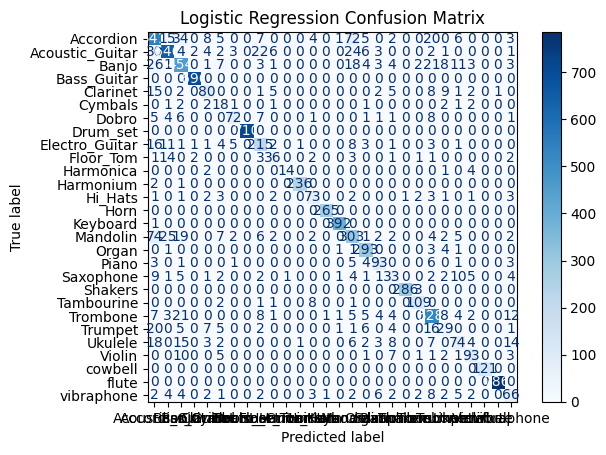

In [ ]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=le.classes_
)

disp_lr.plot(cmap='Blues')

plt.title('Logistic Regression Confusion Matrix')

plt.show()

In [ ]:
import os
import numpy as np
import librosa
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from google.colab import drive

# Mount Google Drive to access your dataset
drive.mount('/content/drive', force_remount=True)

# Define the path to your music dataset
dataset_path = '/content/drive/MyDrive/archive/music_dataset/music_dataset'

# Initialize lists to store extracted features and labels
data_features = []
labels_raw = []

# Define maximum padding length for MFCC features
max_pad_len = 130

# Check if the dataset path exists
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

# Iterate through each genre folder and audio file
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        # Process only WAV files
        if file.endswith(".wav"):
            try:
                # Load audio file, limiting duration to 3 seconds
                audio, sr = librosa.load(file_path, duration=3)

                # Extract MFCC features
                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                # Calculate padding width
                pad_width = max_pad_len - mfcc.shape[1]

                # Pad or truncate MFCCs to a consistent length
                if pad_width > 0:
                    mfcc = np.pad(
                        mfcc,
                        pad_width=((0,0),(0,pad_width)),
                        mode='constant'
                    )
                else:
                    mfcc = mfcc[:, :max_pad_len]

                # Append features and labels
                data_features.append(mfcc)
                labels_raw.append(folder)

            except Exception as e:
                print(f"Skipped: {file_path} due to error: {e}")

# Convert lists to numpy arrays
data = np.array(data_features)
labels_array = np.array(labels_raw)

# Encode categorical labels into numerical format
le = LabelEncoder()
labels = le.fit_transform(labels_array)

# Flatten MFCC
X = data
y = labels
X_vec = X.reshape(X.shape[0], -1)

# Train-Test Split
X_train_vec, X_test_vec, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42
)

nb_model = GaussianNB()
nb_model.fit(X_train_vec, y_train)

y_pred_nb = nb_model.predict(X_test_vec)

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted')
rec_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

Mounted at /content/drive


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_vec, y_train)

y_pred_rf = rf_model.predict(X_test_vec)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming X_train_vec, X_test_vec, y_train, y_test, acc_nb, prec_nb, rec_nb, f1_nb,
# acc_rf, prec_rf, rec_rf, f1_rf are already defined from previous cells (0kSsQNbWzVAi and YHu4s2sXZcpS)

# Logistic Regression Model (from cells gGt860zDoYfu, lkXZVD-Qox-9, zD13va68oyNC)
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vec, y_train)
y_pred_lr = lr_model.predict(X_test_vec)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

results = pd.DataFrame({
    "Algorithm": ["Logistic Regression", "Naive Bayes", "Random Forest"],
    "Accuracy": [acc_lr, acc_nb, acc_rf],
    "Precision": [prec_lr, prec_nb, prec_rf],
    "Recall": [rec_lr, rec_nb, rec_rf],
    "F1 Score": [f1_lr, f1_nb, f1_rf]
})

print(results)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


             Algorithm  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.858088   0.857954  0.858088  0.857060
1          Naive Bayes  0.813541   0.841052  0.813541  0.821834
2        Random Forest  0.909961   0.905529  0.909961  0.897261


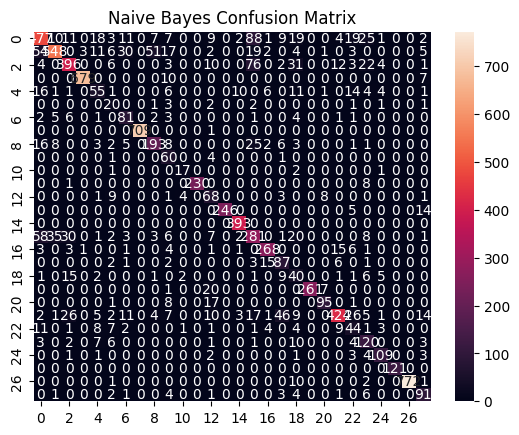

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

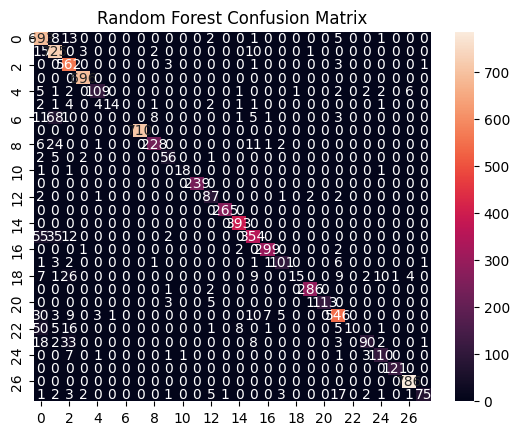

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

print("Naive Bayes")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

print("Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Logistic Regression
                 precision    recall  f1-score   support

      Accordion       0.70      0.75      0.72       723
Acoustic_Guitar       0.89      0.85      0.87       756
          Banjo       0.78      0.80      0.79       570
    Bass_Guitar       0.99      1.00      1.00       696
       Clarinet       0.71      0.61      0.66       131
        Cymbals       0.29      0.58      0.38        31
          Dobro       0.86      0.67      0.75       107
       Drum_set       1.00      1.00      1.00       710
 Electro_Guitar       0.77      0.79      0.78       273
      Floor_Tom       0.63      0.55      0.59        66
      Harmonica       0.93      0.67      0.78        21
      Harmonium       0.99      0.99      0.99       239
        Hi_Hats       0.78      0.77      0.78        95
           Horn       0.99      1.00      1.00       265
       Keyboard       0.99      1.00      0.99       393
       Mandolin       0.67      0.66      0.66       458
          

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


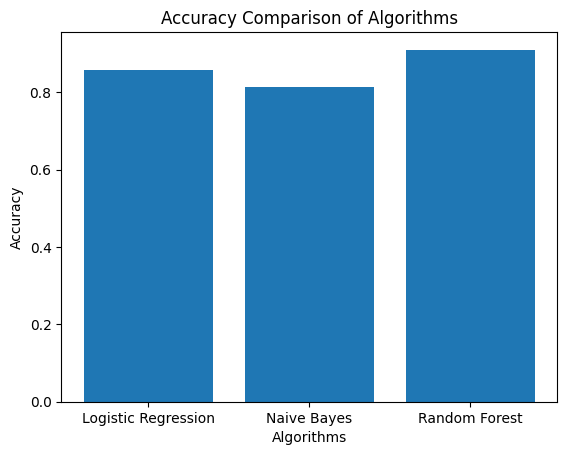

In [ ]:
import matplotlib.pyplot as plt

algorithms = ["Logistic Regression", "Naive Bayes", "Random Forest"]

# Define the accuracy values based on the output of previous cells
acc_lr = 0.858088
acc_nb = 0.813541
acc_rf = 0.909961

accuracy = [acc_lr, acc_nb, acc_rf]

plt.figure()
plt.bar(algorithms, accuracy)
plt.title("Accuracy Comparison of Algorithms")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.show()

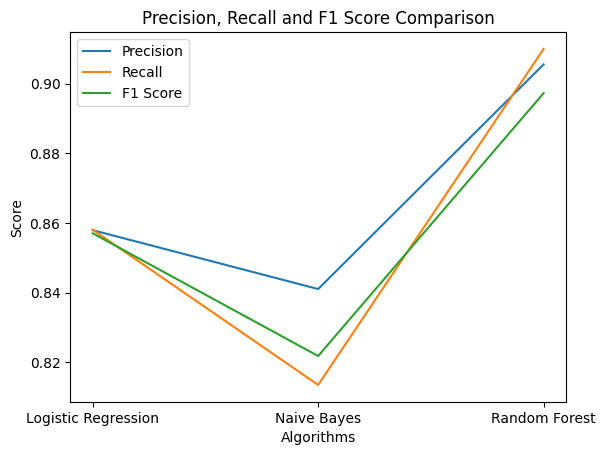

In [ ]:
import matplotlib.pyplot as plt

# Define the metric values based on the output of previous cells (from S4CbUI4bZci7)
prec_lr = 0.857954
prec_nb = 0.841052
prec_rf = 0.905529

rec_lr = 0.858088
rec_nb = 0.813541
rec_rf = 0.909961

f1_lr = 0.857060
f1_nb = 0.821834
f1_rf = 0.897261

precision = [prec_lr, prec_nb, prec_rf]
recall = [rec_lr, rec_nb, rec_rf]
f1 = [f1_lr, f1_nb, f1_rf]

algorithms = ["Logistic Regression", "Naive Bayes", "Random Forest"]

plt.figure()
plt.plot(algorithms, precision, label='Precision')
plt.plot(algorithms, recall, label='Recall')
plt.plot(algorithms, f1, label='F1 Score')

plt.title("Precision, Recall and F1 Score Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Score")
plt.legend()
plt.show()

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


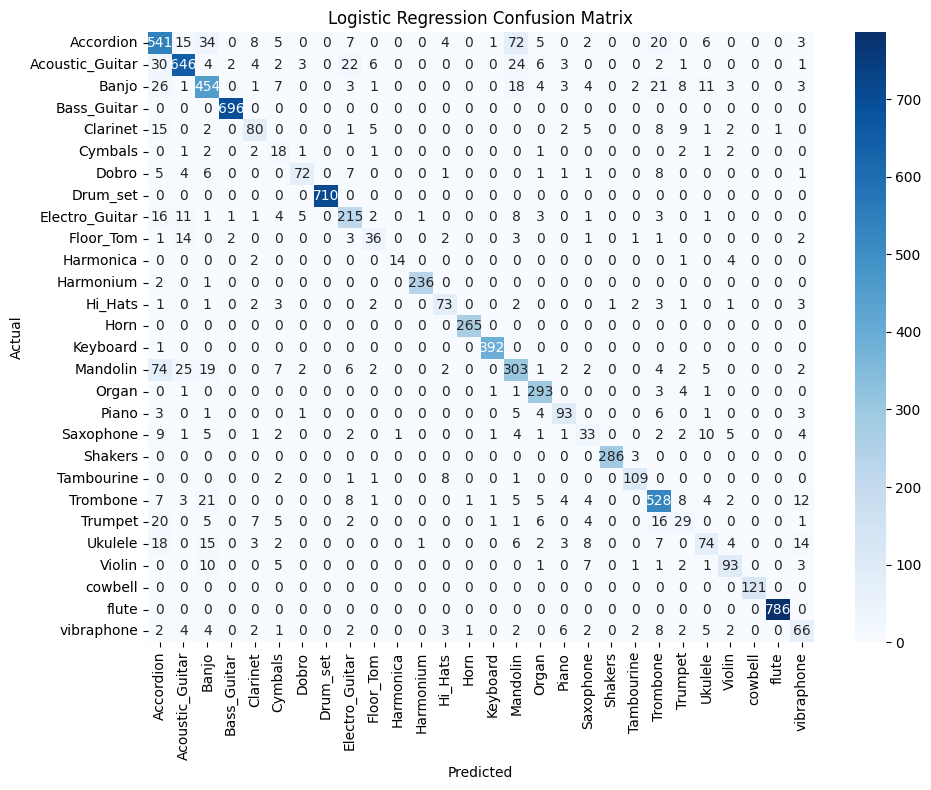

In [ ]:
import os
import numpy as np
import librosa
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive to access your dataset
drive.mount('/content/drive', force_remount=True)

# Define the path to your music dataset
dataset_path = '/content/drive/MyDrive/archive/music_dataset/music_dataset'

# Initialize lists to store extracted features and labels
data_features = []
labels_raw = []

# Define maximum padding length for MFCC features
max_pad_len = 130

# Check if the dataset path exists
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

# Iterate through each genre folder and audio file
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        # Process only WAV files
        if file.endswith(".wav"):
            try:
                # Load audio file, limiting duration to 3 seconds
                audio, sr = librosa.load(file_path, duration=3)

                # Extract MFCC features
                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                # Calculate padding width
                pad_width = max_pad_len - mfcc.shape[1]

                # Pad or truncate MFCCs to a consistent length
                if pad_width > 0:
                    mfcc = np.pad(
                        mfcc,
                        pad_width=((0,0),(0,pad_width)),
                        mode='constant'
                    )
                else:
                    mfcc = mfcc[:, :max_pad_len]

                # Append features and labels
                data_features.append(mfcc)
                labels_raw.append(folder)

            except Exception as e:
                print(f"Skipped: {file_path} due to error: {e}")

# Convert lists to numpy arrays
data = np.array(data_features)
labels_array = np.array(labels_raw)

# Encode categorical labels into numerical format
le = LabelEncoder()
labels = le.fit_transform(labels_array)

# Prepare data for Logistic Regression
X = data
y = labels
X_vec = X.reshape(X.shape[0], -1)

# Train-Test Split
X_train_vec, X_test_vec, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vec, y_train)

y_pred_lr = lr_model.predict(X_test_vec)

# Plot Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Mounted at /content/drive


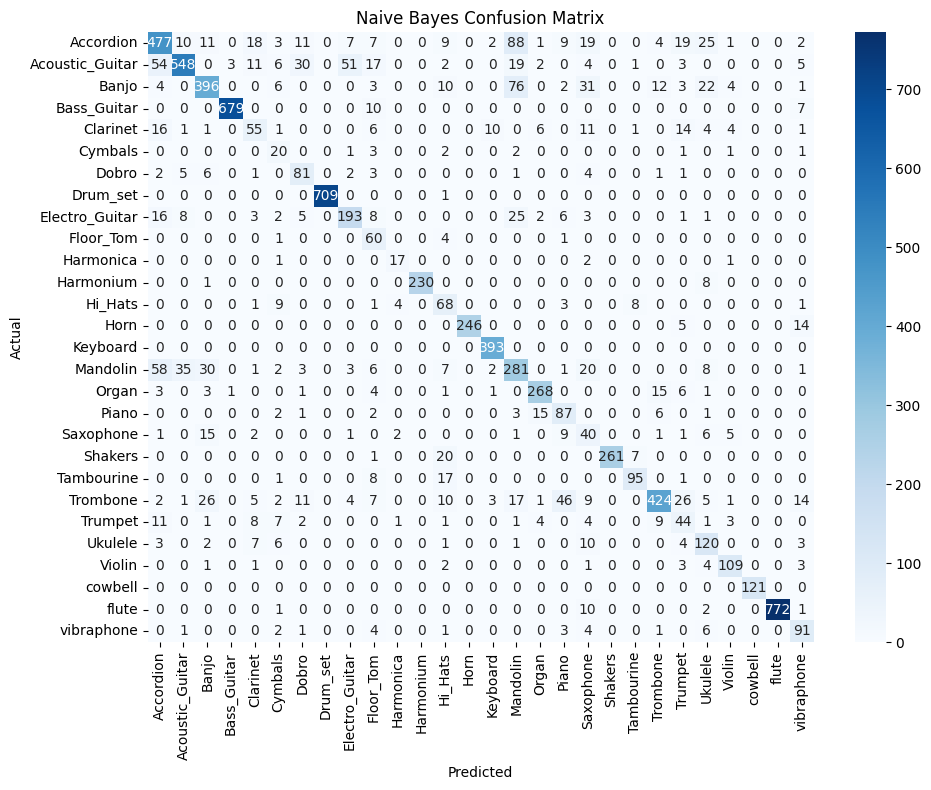

In [ ]:
import os
import numpy as np
import librosa
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive to access your dataset
drive.mount('/content/drive', force_remount=True)

# Define the path to your music dataset
dataset_path = '/content/drive/MyDrive/archive/music_dataset/music_dataset'

# Initialize lists to store extracted features and labels
data_features = []
labels_raw = []

# Define maximum padding length for MFCC features
max_pad_len = 130

# Check if the dataset path exists
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

# Iterate through each genre folder and audio file
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        # Process only WAV files
        if file.endswith(".wav"):
            try:
                # Load audio file, limiting duration to 3 seconds
                audio, sr = librosa.load(file_path, duration=3)

                # Extract MFCC features
                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                # Calculate padding width
                pad_width = max_pad_len - mfcc.shape[1]

                # Pad or truncate MFCCs to a consistent length
                if pad_width > 0:
                    mfcc = np.pad(
                        mfcc,
                        pad_width=((0,0),(0,pad_width)),
                        mode='constant'
                    )
                else:
                    mfcc = mfcc[:, :max_pad_len]

                # Append features and labels
                data_features.append(mfcc)
                labels_raw.append(folder)

            except Exception as e:
                print(f"Skipped: {file_path} due to error: {e}")

# Convert lists to numpy arrays
data = np.array(data_features)
labels_array = np.array(labels_raw)

# Encode categorical labels into numerical format
le = LabelEncoder()
labels = le.fit_transform(labels_array)

# Flatten MFCC
X = data
y = labels
X_vec = X.reshape(X.shape[0], -1)

# Train-Test Split
X_train_vec, X_test_vec, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42
)

# Naive Bayes Model
nb_model = GaussianNB()
nb_model.fit(X_train_vec, y_train)

y_pred_nb = nb_model.predict(X_test_vec)

# Plot Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Mounted at /content/drive


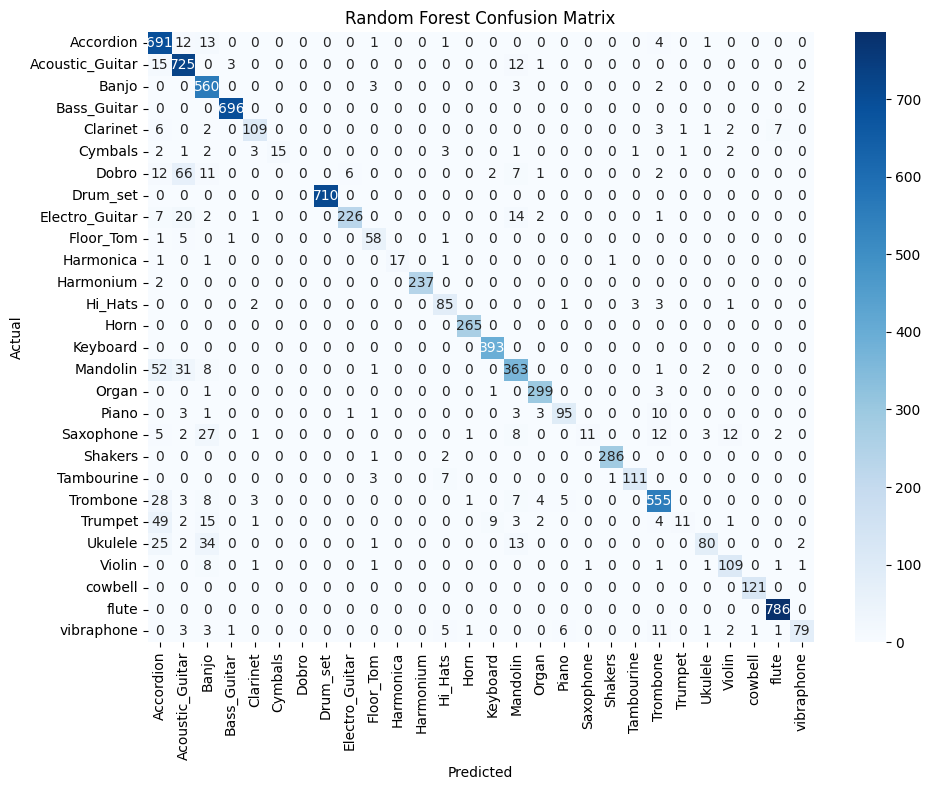

In [ ]:
import os
import numpy as np
import librosa
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive to access your dataset
drive.mount('/content/drive', force_remount=True)

# Define the path to your music dataset
dataset_path = '/content/drive/MyDrive/archive/music_dataset/music_dataset'

# Initialize lists to store extracted features and labels
data_features = []
labels_raw = []

# Define maximum padding length for MFCC features
max_pad_len = 130

# Check if the dataset path exists
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

# Iterate through each genre folder and audio file
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        # Process only WAV files
        if file.endswith(".wav"):
            try:
                # Load audio file, limiting duration to 3 seconds
                audio, sr = librosa.load(file_path, duration=3)

                # Extract MFCC features
                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                # Calculate padding width
                pad_width = max_pad_len - mfcc.shape[1]

                # Pad or truncate MFCCs to a consistent length
                if pad_width > 0:
                    mfcc = np.pad(
                        mfcc,
                        pad_width=((0,0),(0,pad_width)),
                        mode='constant'
                    )
                else:
                    mfcc = mfcc[:, :max_pad_len]

                # Append features and labels
                data_features.append(mfcc)
                labels_raw.append(folder)

            except Exception as e:
                print(f"Skipped: {file_path} due to error: {e}")

# Convert lists to numpy arrays
data = np.array(data_features)
labels_array = np.array(labels_raw)

# Encode categorical labels into numerical format
le = LabelEncoder()
labels = le.fit_transform(labels_array)

# Flatten MFCC
X = data
y = labels
X_vec = X.reshape(X.shape[0], -1)

# Train-Test Split
X_train_vec, X_test_vec, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_vec, y_train)

y_pred_rf = rf_model.predict(X_test_vec)

# Plot Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

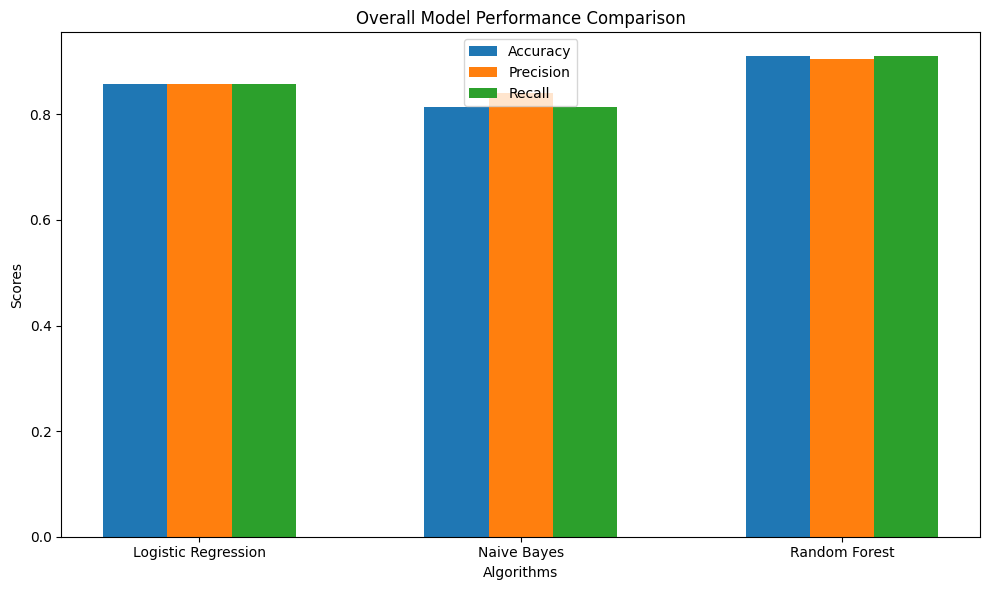

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the metrics based on previous calculations
algorithms = ["Logistic Regression", "Naive Bayes", "Random Forest"]

acc_lr = 0.858088
acc_nb = 0.813541
acc_rf = 0.909961
accuracy = [acc_lr, acc_nb, acc_rf]

prec_lr = 0.857954
prec_nb = 0.841052
prec_rf = 0.905529
precision = [prec_lr, prec_nb, prec_rf]

rec_lr = 0.858088
rec_nb = 0.813541
rec_rf = 0.909961
recall = [rec_lr, rec_nb, rec_rf]

x = np.arange(len(algorithms))

plt.figure(figsize=(10, 6))
plt.bar(x - 0.2, accuracy, 0.2, label='Accuracy')
plt.bar(x, precision, 0.2, label='Precision')
plt.bar(x + 0.2, recall, 0.2, label='Recall')

plt.xticks(x, algorithms)
plt.title("Overall Model Performance Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Scores")
plt.legend()
plt.tight_layout()
plt.show()

Mounted at /content/drive


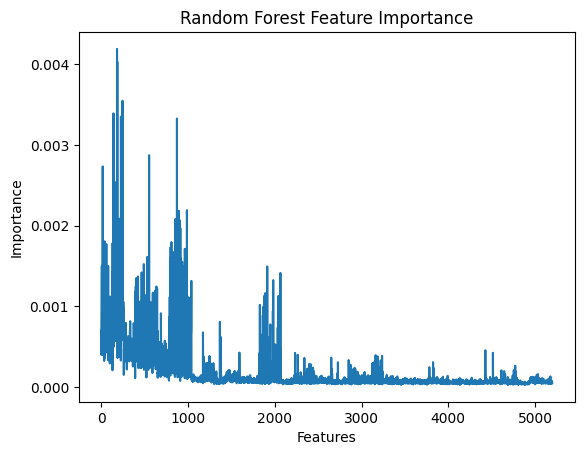

In [ ]:
import os
import numpy as np
import librosa
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive to access your dataset
drive.mount('/content/drive', force_remount=True)

# Define the path to your music dataset
dataset_path = '/content/drive/MyDrive/archive/music_dataset/music_dataset'

# Initialize lists to store extracted features and labels
data_features = []
labels_raw = []

# Define maximum padding length for MFCC features
max_pad_len = 130

# Check if the dataset path exists
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

# Iterate through each genre folder and audio file
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        # Process only WAV files
        if file.endswith(".wav"):
            try:
                # Load audio file, limiting duration to 3 seconds
                audio, sr = librosa.load(file_path, duration=3)

                # Extract MFCC features
                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                # Calculate padding width
                pad_width = max_pad_len - mfcc.shape[1]

                # Pad or truncate MFCCs to a consistent length
                if pad_width > 0:
                    mfcc = np.pad(
                        mfcc,
                        pad_width=((0,0),(0,pad_width)),
                        mode='constant'
                    )
                else:
                    mfcc = mfcc[:, :max_pad_len]

                # Append features and labels
                data_features.append(mfcc)
                labels_raw.append(folder)

            except Exception as e:
                print(f"Skipped: {file_path} due to error: {e}")

# Convert lists to numpy arrays
data = np.array(data_features)
labels_array = np.array(labels_raw)

# Encode categorical labels into numerical format
le = LabelEncoder()
labels = le.fit_transform(labels_array)

# Flatten MFCC
X = data
y = labels
X_vec = X.reshape(X.shape[0], -1)

# Train-Test Split
X_train_vec, X_test_vec, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_vec, y_train)

# Plot Feature Importance
feature_importance = rf_model.feature_importances_

plt.figure()
plt.plot(feature_importance)
plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [ ]:
!pip install flask pyngrok librosa numpy scikit-learn joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd /content/drive/MyDrive/archive/music-project

[Errno 2] No such file or directory: '/content/drive/MyDrive/archive/music-project'
/content


In [ ]:
cd /content/drive/MyDrive/archive/music_dataset/music_dataset

/content/drive/MyDrive/archive/music_dataset/music_dataset


In [ ]:
import joblib
import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from google.colab import drive

# Mount Google Drive to ensure access to dataset if not already mounted
drive.mount('/content/drive', force_remount=True)

# Define the path to your music dataset
dataset_path = '/content/drive/MyDrive/archive/music_dataset/music_dataset'

# Re-load data and features to ensure rf_model and le are defined
data_features = []
labels_raw = []
max_pad_len = 130

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        if file.endswith(".wav"):
            try:
                audio, sr = librosa.load(file_path, duration=3)
                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
                pad_width = max_pad_len - mfcc.shape[1]
                if pad_width > 0:
                    mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)), mode='constant')
                else:
                    mfcc = mfcc[:, :max_pad_len]
                data_features.append(mfcc)
                labels_raw.append(folder)
            except Exception as e:
                print(f"Skipped: {file_path} due to error: {e}")

data = np.array(data_features)
labels_array = np.array(labels_raw)

le = LabelEncoder()
labels = le.fit_transform(labels_array)

X = data
y = labels
X_vec = X.reshape(X.shape[0], -1)

X_train_vec, X_test_vec, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_vec, y_train)

# Define paths to save the model and label encoder
model_save_path = '/content/drive/MyDrive/music-project/instrument_model.pkl'
le_save_path = '/content/drive/MyDrive/music-project/label_encoder.pkl'

# Save the Random Forest model
joblib.dump(rf_model, model_save_path)
print(f"Random Forest model saved to {model_save_path}")

# Save the LabelEncoder
joblib.dump(le, le_save_path)
print(f"Label Encoder saved to {le_save_path}")

In [ ]:
import os

# Create a directory for the Flask application if it doesn't exist
flask_app_dir = '/content/drive/MyDrive/music-project/flask_app'
if not os.path.exists(flask_app_dir):
    os.makedirs(flask_app_dir)
    print(f"Created directory: {flask_app_dir}")

# Create a 'templates' directory inside the Flask app directory
templates_dir = os.path.join(flask_app_dir, 'templates')
if not os.path.exists(templates_dir):
    os.makedirs(templates_dir)
    print(f"Created directory: {templates_dir}")

# Create an 'uploads' directory for storing uploaded audio files temporarily
uploads_dir = os.path.join(flask_app_dir, 'uploads')
if not os.path.exists(uploads_dir):
    os.makedirs(uploads_dir)
    print(f"Created directory: {uploads_dir}")

In [ ]:
%%writefile /content/drive/MyDrive/music-project/flask_app/app.py

import os
import numpy as np
import librosa
import joblib
from flask import Flask, request, render_template, jsonify

app = Flask(__name__)

# Load the trained model and label encoder
MODEL_PATH = '/content/drive/MyDrive/music-project/instrument_model.pkl'
LABEL_ENCODER_PATH = '/content/drive/MyDrive/music-project/label_encoder.pkl'

try:
    model = joblib.load(MODEL_PATH)
    label_encoder = joblib.load(LABEL_ENCODER_PATH)
    print("Model and Label Encoder loaded successfully.")
except Exception as e:
    print(f"Error loading model or label encoder: {e}")
    model = None
    label_encoder = None

# Configuration for uploaded files
UPLOAD_FOLDER = 'uploads'
app.config['UPLOAD_FOLDER'] = UPLOAD_FOLDER

# Ensure the upload folder exists
if not os.path.exists(UPLOAD_FOLDER):
    os.makedirs(UPLOAD_FOLDER)

# Feature extraction function (same as used during training)
def extract_features(audio_path, max_pad_len=130):
    try:
        audio, sr = librosa.load(audio_path, duration=3)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        pad_width = max_pad_len - mfcc.shape[1]
        if pad_width > 0:
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]

        return mfcc.flatten()
    except Exception as e:
        print(f"Error extracting features from {audio_path}: {e}")
        return None

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    if 'audio_file' not in request.files:
        return jsonify({'error': 'No audio file provided'}), 400

    file = request.files['audio_file']
    if file.filename == '':
        return jsonify({'error': 'No selected file'}), 400

    if file and model and label_encoder:
        filepath = os.path.join(app.config['UPLOAD_FOLDER'], file.filename)
        file.save(filepath)

        features = extract_features(filepath)
        if features is None:
            os.remove(filepath)
            return jsonify({'error': 'Failed to extract features from audio file'}), 500

        # Reshape for prediction (single sample)
        features = features.reshape(1, -1)

        prediction = model.predict(features)
        predicted_instrument_idx = prediction[0]
        predicted_instrument = label_encoder.inverse_transform([predicted_instrument_idx])[0]

        os.remove(filepath) # Clean up the uploaded file

        return jsonify({'predicted_instrument': predicted_instrument})
    else:
        return jsonify({'error': 'Model or Label Encoder not loaded properly. Cannot make predictions.'}), 500

if __name__ == '__main__':
    app.run(debug=True, port=5000, use_reloader=False)

In [ ]:
%%writefile /content/drive/MyDrive/music-project/flask_app/templates/index.html

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Instrument Classifier</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 20px; background-color: #f4f4f4; }
        .container { background-color: #fff; padding: 30px; border-radius: 8px; box-shadow: 0 0 10px rgba(0,0,0,0.1); max-width: 600px; margin: auto; }
        h1 { text-align: center; color: #333; }
        form { display: flex; flex-direction: column; align-items: center; }
        input[type="file"] { margin-bottom: 20px; border: 1px solid #ddd; padding: 10px; border-radius: 4px; width: 100%; box-sizing: border-box; }
        button { background-color: #007bff; color: white; padding: 10px 20px; border: none; border-radius: 5px; cursor: pointer; font-size: 16px; }
        button:hover { background-color: #0056b3; }
        #result { margin-top: 20px; text-align: center; font-size: 1.2em; color: #333; }
        #loading { display: none; margin-top: 20px; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Upload Audio for Instrument Classification</h1>
        <form id="uploadForm" enctype="multipart/form-data">
            <input type="file" name="audio_file" accept=".wav" required>
            <button type="submit">Classify Instrument</button>
        </form>
        <div id="loading" style="display: none;">
            <p>Processing audio, please wait...</p>
        </div>
        <div id="result"></div>
    </div>

    <script>
        document.getElementById('uploadForm').addEventListener('submit', async function(event) {
            event.preventDefault();
            const form = event.target;
            const formData = new FormData(form);
            const resultDiv = document.getElementById('result');
            const loadingDiv = document.getElementById('loading');

            resultDiv.textContent = '';
            loadingDiv.style.display = 'block';

            try {
                const response = await fetch('/predict', {
                    method: 'POST',
                    body: formData
                });

                if (!response.ok) {
                    const errorData = await response.json();
                    throw new Error(errorData.error || 'Something went wrong');
                }

                const data = await response.json();
                resultDiv.textContent = `Predicted Instrument: ${data.predicted_instrument}`;
            } catch (error) {
                resultDiv.textContent = `Error: ${error.message}`;
                resultDiv.style.color = 'red';
            } finally {
                loadingDiv.style.display = 'none';
            }
        });
    </script>
</body>
</html>

Overwriting /content/drive/MyDrive/music-project/flask_app/templates/index.html


In [ ]:
cd /content/drive/MyDrive/music-project/flask_app

In [ ]:
!pip install pyngrok # Ensure pyngrok is installed for this execution
from pyngrok import ngrok

# It's crucial to set your authentication token. You have done this in cell 3nVzZQURR3Od.
# Please ensure cell 3nVzZQURR3Od has been executed recently.

# Kill any existing ngrok tunnels
ngrok.kill()

# Start a new ngrok tunnel
public_url = ngrok.connect(5000)
print(f"Flask app accessible at: {public_url}")

# Run the Flask app
!python app.py

In [ ]:
import joblib
import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from google.colab import drive

# Mount Google Drive to ensure access to dataset if not already mounted
drive.mount('/content/drive', force_remount=True)

# Define the path to your music dataset
dataset_path = '/content/drive/MyDrive/archive/music_dataset/music_dataset'

# Re-load data and features to ensure rf_model and le are defined
data_features = []
labels_raw = []
max_pad_len = 130

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        if file.endswith(".wav"):
            try:
                audio, sr = librosa.load(file_path, duration=3)
                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
                pad_width = max_pad_len - mfcc.shape[1]
                if pad_width > 0:
                    mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)), mode='constant')
                else:
                    mfcc = mfcc[:, :max_pad_len]
                data_features.append(mfcc)
                labels_raw.append(folder)
            except Exception as e:
                print(f"Skipped: {file_path} due to error: {e}")

data = np.array(data_features)
labels_array = np.array(labels_raw)

le = LabelEncoder()
labels = le.fit_transform(labels_array)

X = data
y = labels
X_vec = X.reshape(X.shape[0], -1)

X_train_vec, X_test_vec, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_vec, y_train)

# Define paths to save the model and label encoder
model_save_path = '/content/drive/MyDrive/music-project/instrument_model.pkl'
le_save_path = '/content/drive/MyDrive/music-project/label_encoder.pkl'

# Save the Random Forest model
joblib.dump(rf_model, model_save_path)
print(f"Random Forest model saved to {model_save_path}")

# Save the LabelEncoder
joblib.dump(le, le_save_path)
print(f"Label Encoder saved to {le_save_path}")

In [ ]:
import os

# Create a directory for the Flask application if it doesn't exist
flask_app_dir = '/content/drive/MyDrive/music-project/flask_app'
if not os.path.exists(flask_app_dir):
    os.makedirs(flask_app_dir)
    print(f"Created directory: {flask_app_dir}")

# Create a 'templates' directory inside the Flask app directory
templates_dir = os.path.join(flask_app_dir, 'templates')
if not os.path.exists(templates_dir):
    os.makedirs(templates_dir)
    print(f"Created directory: {templates_dir}")

# Create an 'uploads' directory for storing uploaded audio files temporarily
uploads_dir = os.path.join(flask_app_dir, 'uploads')
if not os.path.exists(uploads_dir):
    os.makedirs(uploads_dir)
    print(f"Created directory: {uploads_dir}")

In [ ]:
%%writefile /content/drive/MyDrive/music-project/flask_app/app.py

import os
import numpy as np
import librosa
import joblib
from flask import Flask, request, render_template, jsonify

app = Flask(__name__)

# Load the trained model and label encoder
MODEL_PATH = '/content/drive/MyDrive/music-project/instrument_model.pkl'
LABEL_ENCODER_PATH = '/content/drive/MyDrive/music-project/label_encoder.pkl'

try:
    model = joblib.load(MODEL_PATH)
    label_encoder = joblib.load(LABEL_ENCODER_PATH)
    print("Model and Label Encoder loaded successfully.")
except Exception as e:
    print(f"Error loading model or label encoder: {e}")
    model = None
    label_encoder = None

# Configuration for uploaded files
UPLOAD_FOLDER = 'uploads'
app.config['UPLOAD_FOLDER'] = UPLOAD_FOLDER

# Ensure the upload folder exists
if not os.path.exists(UPLOAD_FOLDER):
    os.makedirs(UPLOAD_FOLDER)

# Feature extraction function (same as used during training)
def extract_features(audio_path, max_pad_len=130):
    try:
        audio, sr = librosa.load(audio_path, duration=3)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        pad_width = max_pad_len - mfcc.shape[1]
        if pad_width > 0:
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]

        return mfcc.flatten()
    except Exception as e:
        print(f"Error extracting features from {audio_path}: {e}")
        return None

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    if 'audio_file' not in request.files:
        return jsonify({'error': 'No audio file provided'}), 400

    file = request.files['audio_file']
    if file.filename == '':
        return jsonify({'error': 'No selected file'}), 400

    if file and model and label_encoder:
        filepath = os.path.join(app.config['UPLOAD_FOLDER'], file.filename)
        file.save(filepath)

        features = extract_features(filepath)
        if features is None:
            os.remove(filepath)
            return jsonify({'error': 'Failed to extract features from audio file'}), 500

        # Reshape for prediction (single sample)
        features = features.reshape(1, -1)

        prediction = model.predict(features)
        predicted_instrument_idx = prediction[0]
        predicted_instrument = label_encoder.inverse_transform([predicted_instrument_idx])[0]

        os.remove(filepath) # Clean up the uploaded file

        return jsonify({'predicted_instrument': predicted_instrument})
    else:
        return jsonify({'error': 'Model or Label Encoder not loaded properly. Cannot make predictions.'}), 500

if __name__ == '__main__':
    app.run(debug=True, port=5000, use_reloader=False)

In [ ]:
%%writefile /content/drive/MyDrive/music-project/flask_app/templates/index.html

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Instrument Classifier</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 20px; background-color: #f4f4f4; }
        .container { background-color: #fff; padding: 30px; border-radius: 8px; box-shadow: 0 0 10px rgba(0,0,0,0.1); max-width: 600px; margin: auto; }
        h1 { text-align: center; color: #333; }
        form { display: flex; flex-direction: column; align-items: center; }
        input[type="file"] { margin-bottom: 20px; border: 1px solid #ddd; padding: 10px; border-radius: 4px; width: 100%; box-sizing: border-box; }
        button { background-color: #007bff; color: white; padding: 10px 20px; border: none; border-radius: 5px; cursor: pointer; font-size: 16px; }
        button:hover { background-color: #0056b3; }
        #result { margin-top: 20px; text-align: center; font-size: 1.2em; color: #333; }
        #loading { display: none; margin-top: 20px; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Upload Audio for Instrument Classification</h1>
        <form id="uploadForm" enctype="multipart/form-data">
            <input type="file" name="audio_file" accept=".wav" required>
            <button type="submit">Classify Instrument</button>
        </form>
        <div id="loading" style="display: none;">
            <p>Processing audio, please wait...</p>
        </div>
        <div id="result"></div>
    </div>

    <script>
        document.getElementById('uploadForm').addEventListener('submit', async function(event) {
            event.preventDefault();
            const form = event.target;
            const formData = new FormData(form);
            const resultDiv = document.getElementById('result');
            const loadingDiv = document.getElementById('loading');

            resultDiv.textContent = '';
            loadingDiv.style.display = 'block';

            try {
                const response = await fetch('/predict', {
                    method: 'POST',
                    body: formData
                });

                if (!response.ok) {
                    const errorData = await response.json();
                    throw new Error(errorData.error || 'Something went wrong');
                }

                const data = await response.json();
                resultDiv.textContent = `Predicted Instrument: ${data.predicted_instrument}`;
            } catch (error) {
                resultDiv.textContent = `Error: ${error.message}`;
                resultDiv.style.color = 'red';
            } finally {
                loadingDiv.style.display = 'none';
            }
        });
    </script>
</body>
</html>

In [ ]:
cd /content/drive/MyDrive/music-project/flask_app

In [ ]:
!pip install pyngrok # Ensure pyngrok is installed for this execution
from pyngrok import ngrok

# It's crucial to set your authentication token. You have done this in cell 3nVzZQURR3Od.
# Please ensure cell 3nVzZQURR3Od has been executed recently.

# Kill any existing ngrok tunnels
ngrok.kill()

# Start a new ngrok tunnel
public_url = ngrok.connect(5000)
print(f"Flask app accessible at: {public_url}")

# Run the Flask app
!python app.py

In [ ]:
import joblib
import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from google.colab import drive

# Mount Google Drive to ensure access to dataset if not already mounted
drive.mount('/content/drive', force_remount=True)

# Define the path to your music dataset
dataset_path = '/content/drive/MyDrive/archive/music_dataset/music_dataset'

# Re-load data and features to ensure rf_model and le are defined
data_features = []
labels_raw = []
max_pad_len = 130

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        if file.endswith(".wav"):
            try:
                audio, sr = librosa.load(file_path, duration=3)
                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
                pad_width = max_pad_len - mfcc.shape[1]
                if pad_width > 0:
                    mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)), mode='constant')
                else:
                    mfcc = mfcc[:, :max_pad_len]
                data_features.append(mfcc)
                labels_raw.append(folder)
            except Exception as e:
                print(f"Skipped: {file_path} due to error: {e}")

data = np.array(data_features)
labels_array = np.array(labels_raw)

le = LabelEncoder()
labels = le.fit_transform(labels_array)

X = data
y = labels
X_vec = X.reshape(X.shape[0], -1)

X_train_vec, X_test_vec, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_vec, y_train)

# Define paths to save the model and label encoder
model_save_path = '/content/drive/MyDrive/music-project/instrument_model.pkl'
le_save_path = '/content/drive/MyDrive/music-project/label_encoder.pkl'

# Save the Random Forest model
joblib.dump(rf_model, model_save_path)
print(f"Random Forest model saved to {model_save_path}")

# Save the LabelEncoder
joblib.dump(le, le_save_path)
print(f"Label Encoder saved to {le_save_path}")

NameError: name 'rf_model' is not defined

Now that the model and label encoder are saved, I'll create the necessary files for a Flask web application that can serve this model. We'll need `app.py` for the Flask application logic and `templates/index.html` for the user interface.

In [ ]:
import os

# Create a directory for the Flask application if it doesn't exist
flask_app_dir = '/content/drive/MyDrive/music-project/flask_app'
if not os.path.exists(flask_app_dir):
    os.makedirs(flask_app_dir)
    print(f"Created directory: {flask_app_dir}")

# Create a 'templates' directory inside the Flask app directory
templates_dir = os.path.join(flask_app_dir, 'templates')
if not os.path.exists(templates_dir):
    os.makedirs(templates_dir)
    print(f"Created directory: {templates_dir}")

# Create an 'uploads' directory for storing uploaded audio files temporarily
uploads_dir = os.path.join(flask_app_dir, 'uploads')
if not os.path.exists(uploads_dir):
    os.makedirs(uploads_dir)
    print(f"Created directory: {uploads_dir}")

Created directory: /content/drive/MyDrive/music-project/flask_app
Created directory: /content/drive/MyDrive/music-project/flask_app/templates
Created directory: /content/drive/MyDrive/music-project/flask_app/uploads


Next, I'll create the `app.py` file, which will contain the Flask application code, and an `index.html` file for the web interface. Make sure you have your ngrok authentication token set up if you want to expose this publicly.

In [ ]:
%%writefile /content/drive/MyDrive/music-project/flask_app/app.py

import os
import numpy as np
import librosa
import joblib
from flask import Flask, request, render_template, jsonify

app = Flask(__name__)

# Load the trained model and label encoder
MODEL_PATH = '/content/drive/MyDrive/music-project/instrument_model.pkl'
LABEL_ENCODER_PATH = '/content/drive/MyDrive/music-project/label_encoder.pkl'

try:
    model = joblib.load(MODEL_PATH)
    label_encoder = joblib.load(LABEL_ENCODER_PATH)
    print("Model and Label Encoder loaded successfully.")
except Exception as e:
    print(f"Error loading model or label encoder: {e}")
    model = None
    label_encoder = None

# Configuration for uploaded files
UPLOAD_FOLDER = 'uploads'
app.config['UPLOAD_FOLDER'] = UPLOAD_FOLDER

# Ensure the upload folder exists
if not os.path.exists(UPLOAD_FOLDER):
    os.makedirs(UPLOAD_FOLDER)

# Feature extraction function (same as used during training)
def extract_features(audio_path, max_pad_len=130):
    try:
        audio, sr = librosa.load(audio_path, duration=3)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        pad_width = max_pad_len - mfcc.shape[1]
        if pad_width > 0:
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]

        return mfcc.flatten()
    except Exception as e:
        print(f"Error extracting features from {audio_path}: {e}")
        return None

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    if 'audio_file' not in request.files:
        return jsonify({'error': 'No audio file provided'}), 400

    file = request.files['audio_file']
    if file.filename == '':
        return jsonify({'error': 'No selected file'}), 400

    if file and model and label_encoder:
        filepath = os.path.join(app.config['UPLOAD_FOLDER'], file.filename)
        file.save(filepath)

        features = extract_features(filepath)
        if features is None:
            os.remove(filepath)
            return jsonify({'error': 'Failed to extract features from audio file'}), 500

        # Reshape for prediction (single sample)
        features = features.reshape(1, -1)

        prediction = model.predict(features)
        predicted_instrument_idx = prediction[0]
        predicted_instrument = label_encoder.inverse_transform([predicted_instrument_idx])[0]

        os.remove(filepath) # Clean up the uploaded file

        return jsonify({'predicted_instrument': predicted_instrument})
    else:
        return jsonify({'error': 'Model or Label Encoder not loaded properly. Cannot make predictions.'}), 500

if __name__ == '__main__':
    app.run(debug=True, port=5000, use_reloader=False)

Writing /content/drive/MyDrive/music-project/flask_app/app.py


In [ ]:
%%writefile /content/drive/MyDrive/music-project/flask_app/templates/index.html

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Instrument Classifier</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 20px; background-color: #f4f4f4; }
        .container { background-color: #fff; padding: 30px; border-radius: 8px; box-shadow: 0 0 10px rgba(0,0,0,0.1); max-width: 600px; margin: auto; }
        h1 { text-align: center; color: #333; }
        form { display: flex; flex-direction: column; align-items: center; }
        input[type="file"] { margin-bottom: 20px; border: 1px solid #ddd; padding: 10px; border-radius: 4px; width: 100%; box-sizing: border-box; }
        button { background-color: #007bff; color: white; padding: 10px 20px; border: none; border-radius: 5px; cursor: pointer; font-size: 16px; }
        button:hover { background-color: #0056b3; }
        #result { margin-top: 20px; text-align: center; font-size: 1.2em; color: #333; }
        #loading { display: none; margin-top: 20px; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Upload Audio for Instrument Classification</h1>
        <form id="uploadForm" enctype="multipart/form-data">
            <input type="file" name="audio_file" accept=".wav" required>
            <button type="submit">Classify Instrument</button>
        </form>
        <div id="loading" style="display: none;">
            <p>Processing audio, please wait...</p>
        </div>
        <div id="result"></div>
    </div>

    <script>
        document.getElementById('uploadForm').addEventListener('submit', async function(event) {
            event.preventDefault();
            const form = event.target;
            const formData = new FormData(form);
            const resultDiv = document.getElementById('result');
            const loadingDiv = document.getElementById('loading');

            resultDiv.textContent = '';
            loadingDiv.style.display = 'block';

            try {
                const response = await fetch('/predict', {
                    method: 'POST',
                    body: formData
                });

                if (!response.ok) {
                    const errorData = await response.json();
                    throw new Error(errorData.error || 'Something went wrong');
                }

                const data = await response.json();
                resultDiv.textContent = `Predicted Instrument: ${data.predicted_instrument}`;
            } catch (error) {
                resultDiv.textContent = `Error: ${error.message}`;
                resultDiv.style.color = 'red';
            } finally {
                loadingDiv.style.display = 'none';
            }
        });
    </script>
</body>
</html>

Writing /content/drive/MyDrive/music-project/flask_app/templates/index.html


To run your Flask application and make it accessible, you'll need to execute the `app.py` file. Since you are in Google Colab, we'll use `ngrok` to expose your local Flask server to the internet. **Make sure your ngrok authentication token is configured in a previous cell (`3nVzZQURR3Od`) and run it again if it isn't set up yet.**

First, navigate to the `flask_app` directory:


In [ ]:
cd /content/drive/MyDrive/music-project/flask_app

/content/drive/MyDrive/music-project/flask_app


Then, run the Flask application. This will start the web server, and `ngrok` will provide a public URL you can access.

In [ ]:
!pip install pyngrok # Ensure pyngrok is installed for this execution
from pyngrok import ngrok

# It's crucial to set your authentication token. You have done this in cell 3nVzZQURR3Od.
# Please ensure cell 3nVzZQURR3Od has been executed recently.

# Kill any existing ngrok tunnels
ngrok.kill()

# Start a new ngrok tunnel
public_url = ngrok.connect(5000)
print(f"Flask app accessible at: {public_url}")

# Run the Flask app
!python app.py

ModuleNotFoundError: No module named 'pyngrok'

In [ ]:
!ls

Accordion	 Drum_set	 instrument_model.pkl  Tambourine
Acoustic_Guitar  Electro_Guitar  Keyboard	       Trombone
Banjo		 Floor_Tom	 label_encoder.pkl     Trumpet
Bass_Guitar	 flute		 Mandolin	       Ukulele
Clarinet	 Harmonica	 Organ		       vibraphone
cowbell		 Harmonium	 Piano		       Violin
Cymbals		 Hi_Hats	 Saxophone
Dobro		 Horn		 Shakers


In [ ]:
!pip install flask pyngrok librosa numpy scikit-learn joblib

In [ ]:
cd ..

/


In [ ]:
!ls

bin	 datalab  home	  lib32   media  proc		    root  srv  tools
boot	 dev	  kaggle  lib64   mnt	 python-apt	    run   sys  usr
content  etc	  lib	  libx32  opt	 python-apt.tar.xz  sbin  tmp  var


In [ ]:
!ls /content/drive/MyDrive

'0801IT231044_Dhruv  Garg.docx'   archive  'Colab Notebooks'


In [ ]:
cd /content/drive/MyDrive/archive

/content/drive/MyDrive/archive


In [ ]:
!ls

music_dataset


In [ ]:
!cd /content/drive/MyDrive/archive/music_dataset
!ls

music_dataset


In [ ]:
!cd /content/drive/MyDrive/archive/music_dataset/music_dataset
!ls

music_dataset


In [ ]:
!find /content/drive/MyDrive -name "*.pkl"

/content/drive/MyDrive/archive/music_dataset/music_dataset/instrument_model.pkl
/content/drive/MyDrive/archive/music_dataset/music_dataset/label_encoder.pkl


In [ ]:
!mkdir /content/drive/MyDrive/music-project

In [ ]:
!mv /content/drive/MyDrive/Colab\ Notebooks/instrument_model.pkl /content/drive/MyDrive/music-project/

mv: cannot stat '/content/drive/MyDrive/Colab Notebooks/instrument_model.pkl': No such file or directory


In [ ]:
!cd /content/drive/MyDrive/music-project
!ls

Accordion	 Drum_set	 instrument_model.pkl  Tambourine
Acoustic_Guitar  Electro_Guitar  Keyboard	       Trombone
Banjo		 Floor_Tom	 label_encoder.pkl     Trumpet
Bass_Guitar	 flute		 Mandolin	       Ukulele
Clarinet	 Harmonica	 Organ		       vibraphone
cowbell		 Harmonium	 Piano		       Violin
Cymbals		 Hi_Hats	 Saxophone
Dobro		 Horn		 Shakers


In [ ]:
!find /content/drive/MyDrive -name "*.pkl"

/content/drive/MyDrive/archive/music_dataset/music_dataset/instrument_model.pkl
/content/drive/MyDrive/archive/music_dataset/music_dataset/label_encoder.pkl


In [ ]:
!cd /content/drive/MyDrive/music-project
!ls

Accordion	 Drum_set	 instrument_model.pkl  Tambourine
Acoustic_Guitar  Electro_Guitar  Keyboard	       Trombone
Banjo		 Floor_Tom	 label_encoder.pkl     Trumpet
Bass_Guitar	 flute		 Mandolin	       Ukulele
Clarinet	 Harmonica	 Organ		       vibraphone
cowbell		 Harmonium	 Piano		       Violin
Cymbals		 Hi_Hats	 Saxophone
Dobro		 Horn		 Shakers


In [ ]:
!pip install flask pyngrok librosa numpy scikit-learn joblib

In [ ]:
from pyngrok import ngrok

# Replace "YOUR_NGROK_TOKEN" with your actual ngrok authentication token
ngrok.set_auth_token("3BLBycEBrch1oFtcvuJ7vhqDnd2_69JMNaboV5eXFHsTrdCRB")

public_url = ngrok.connect(5000)

print(public_url)

NgrokTunnel: "https://chronogrammatically-tectonic-nick.ngrok-free.dev" -> "http://localhost:5000"


In [ ]:
cd /content/drive/MyDrive/music-project

/content/drive/MyDrive/music-project


In [ ]:
!ls

In [ ]:
import joblib

joblib.dump(rf_model, "instrument_model.pkl")
joblib.dump(le, "label_encoder.pkl")

NameError: name 'rf_model' is not defined

In [ ]:
import joblib
import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from google.colab import drive

# Mount Google Drive to ensure access to dataset if not already mounted
drive.mount('/content/drive', force_remount=True)

# Define the path to your music dataset
dataset_path = '/content/drive/MyDrive/archive/music_dataset/music_dataset'

# Re-load data and features to ensure rf_model and le are defined
data_features = []
labels_raw = []
max_pad_len = 130

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        if file.endswith(".wav"):
            try:
                audio, sr = librosa.load(file_path, duration=3)
                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
                pad_width = max_pad_len - mfcc.shape[1]
                if pad_width > 0:
                    mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)), mode='constant')
                else:
                    mfcc = mfcc[:, :max_pad_len]
                data_features.append(mfcc)
                labels_raw.append(folder)
            except Exception as e:
                print(f"Skipped: {file_path} due to error: {e}")

data = np.array(data_features)
labels_array = np.array(labels_raw)

le = LabelEncoder()
labels = le.fit_transform(labels_array)

X = data
y = labels
X_vec = X.reshape(X.shape[0], -1)

X_train_vec, X_test_vec, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_vec, y_train)

# Define paths to save the model and label encoder
model_save_path = '/content/drive/MyDrive/music-project/instrument_model.pkl'
le_save_path = '/content/drive/MyDrive/music-project/label_encoder.pkl'

# Save the Random Forest model
joblib.dump(rf_model, model_save_path)
print(f"Random Forest model saved to {model_save_path}")

# Save the LabelEncoder
joblib.dump(le, le_save_path)
print(f"Label Encoder saved to {le_save_path}")

Mounted at /content/drive
Random Forest model saved to /content/drive/MyDrive/music-project/instrument_model.pkl
Label Encoder saved to /content/drive/MyDrive/music-project/label_encoder.pkl
